<a href="https://colab.research.google.com/github/FDC-PyArch8/z5688839-PHYS2116-Computational-Assignment/blob/main/z5688839_computational_assignment_megno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rebound
!pip install multiprocess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 13.7 MB/s eta 0:00:00


In [3]:
import rebound
import math
from multiprocess import Pool
import numpy as np

In [4]:
"""
# test simulation of sun and Earth-mass planet

# initialising simulation
sim_sun = rebound.Simulation()

# formatting the value of G to fit the units below
sim_sun.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_sun.G))

# adding particles of mass m and semi-major axis a
sim_sun.add(m=1.0)
sim_sun.add(m=1.0e-3, a=1.0)

#integrating orbit
sim_sun.integrate(10000)
orbits = sim_sun.orbits()
for o in orbits:
    print(o.a, o.e)
"""

'\n# test simulation of sun and Earth-mass planet\n\n# initialising simulation\nsim_sun = rebound.Simulation()\n\n# formatting the value of G to fit the units below\nsim_sun.units = (\'yr\', \'AU\', \'Msun\')\nprint("G = {0}.".format(sim_sun.G))\n\n# adding particles of mass m and semi-major axis a\nsim_sun.add(m=1.0)\nsim_sun.add(m=1.0e-3, a=1.0)\n\n#integrating orbit\nsim_sun.integrate(10000)\norbits = sim_sun.orbits()\nfor o in orbits:\n    print(o.a, o.e)\n'

In [5]:
"""
# initialising orbit of an equal-mass binary star system
sim_two_body = rebound.Simulation()
sim_two_body.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_two_body.G))

# adding particles with x-position x and y-velocity vy
sim_two_body.add(m=1.0)
sim_two_body.add(m=1.0, x=1, vy=1)
sim_two_body.status()

# integrating for 8000 years with timesteps of 1 yr
sim_two_body.integrate(8000)

# setting centre of mass at 0 to reduce numerical error
sim_two_body.move_to_com()
sim_two_body.status()
orbits = sim_two_body.orbits()
for o in orbits:
    print(o.a, o.e)
"""

'\n# initialising orbit of an equal-mass binary star system\nsim_two_body = rebound.Simulation()\nsim_two_body.units = (\'yr\', \'AU\', \'Msun\')\nprint("G = {0}.".format(sim_two_body.G))\n\n# adding particles with x-position x and y-velocity vy\nsim_two_body.add(m=1.0)\nsim_two_body.add(m=1.0, x=1, vy=1)\nsim_two_body.status()\n\n# integrating for 8000 years with timesteps of 1 yr\nsim_two_body.integrate(8000)\n\n# setting centre of mass at 0 to reduce numerical error\nsim_two_body.move_to_com()\nsim_two_body.status()\norbits = sim_two_body.orbits()\nfor o in orbits:\n    print(o.a, o.e)\n'

In [6]:
# op = rebound.OrbitPlotSet(sim_two_body)

In [7]:
# parsec = au / arcsec
def au(arcsec):
  distance_parsecs = 1.34
  au = distance_parsecs * arcsec
  return au

def radians(degrees):
    return degrees * (math.pi / 180)

In [8]:
au(17.4930)

23.44062

In [21]:
# initialising the simulation and setting a value for G which gives the below units
sim_centauri = rebound.Simulation()
# sim_centauri.start_server(port=1234) #used for 3d animation
# sim_centauri.widget(size=(400,400))
sim_centauri.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_centauri.G))

# initialising trinary system by adding particles
sim_centauri.add(m=1.0788, hash="cen_a")
sim_centauri.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
                 Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
sim_centauri.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),
                 Omega=radians(165), omega=radians(151.0), T=278e3,
                 hash="prox_cen")
sim_centauri.add(m=0.001, a=10)
sim_centauri.status()
sim_centauri.move_to_com()  # setting centre of mass at 0 to reduce numerical error

#references: https://www.mdpi.com/2218-1997/10/2/64,
#            https://iopscience.iop.org/article/10.3847/1538-3881/abfaff/pdf
#            https://www.stellarcatalog.com/stars/proxima-centauri

sim_centauri.init_megno() # initialising chaos indicators

years = 100000
sim_centauri.integrate(years)
sim_centauri.status()
orbits = sim_centauri.orbits()

G = 39.476926421373.
---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	4
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7a1b246d4a50, m=1.0788 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x7a1b246d5350, m=0.9092 x=-18.696523979377055 y=-14.28867265104223 z=26.419040799861133 vx=0.7430779931127516 vy=0.20312296253892428 vz=0.6890830002453935>
<rebound.particle.Particle object at 0x7a1b246d4a50, m=0.122 x=-10691.342594613147 y=-1304.7679124414537 z=-5748.885259890657 vx=0.3089037306841255 vy=0.12754657943143172 vz=0.35164601179503097>
<rebound.particle.Particle object at 0x7a1b246d5350, m=0.001 x=-616.2287564667552 y=-81.59855283989809 z=-321.01602360731107 vx=0.33805344383013136 vy=2.9816944373276075 vz=0.31725833045597424>
---------------------------

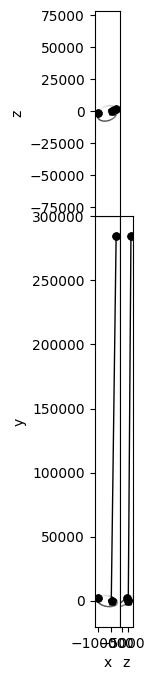

In [22]:
op3 = rebound.OrbitPlotSet(sim_centauri)

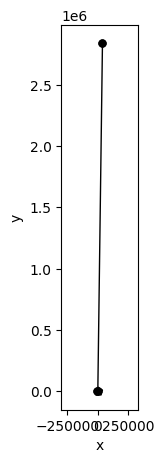

In [11]:
# attempt at an animation
op = rebound.OrbitPlot(sim_centauri)
fig = op.fig
for i in range(3):
    sim_centauri.integrate(sim_centauri.t+0.31)
    op3.update()
    op3.fig.savefig("out_%02d.png"%i)


In [12]:
print("MEGNO", sim_centauri.megno())
print("LCN", sim_centauri.lyapunov())
# MEGNO:
# -> infinity: chaotic
# -> 2: quasi-periodic
# https://orbi.uliege.be/bitstream/2268/290365/1/OPS2018_Poster_Pozuelos.pdf

MEGNO 2.1874378156264873
LCN 2.49466828478965e-07


In [13]:
print("MEGNO", sim_centauri.megno())
print("LCN", sim_centauri.lyapunov())

MEGNO 2.1874378156264873
LCN 2.49466828478965e-07


In [14]:
# simulation
def cen_sim(par):
    a = par[0]
    e = par[1]
    sim = rebound.Simulation()
    sim.add(m=1.0788, hash="cen_a")
    sim.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
            Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
    sim.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),
            Omega=radians(165), omega=radians(151.0), T=278e3,
            hash="prox_cen")
    sim.move_to_com()

    sim.init_megno()
    sim.exit_max_distance = 10e3
    try:
        sim.integrate(1e2) # integrate for 500 years
        megno = sim.megno()
        return megno
    except rebound.Escape:
        return 10. # At least one particle got ejected, returning large MEGNO.

In [15]:
# test function with one set of semi-major axis and eccentricity
cen_sim((7,0.1))

1.9637127957953624

In [16]:
# using code from the stability map example on the REBOUND website
with Pool() as pool:
    Ngrid = 100
    par_a = np.linspace(0.01, 9e3, Ngrid)
    par_e = np.linspace(0.,1, Ngrid)
    parameters = []
    for e in par_e:
        for a in par_a:
            parameters.append((a,e))
    results = pool.map(cen_sim,parameters)

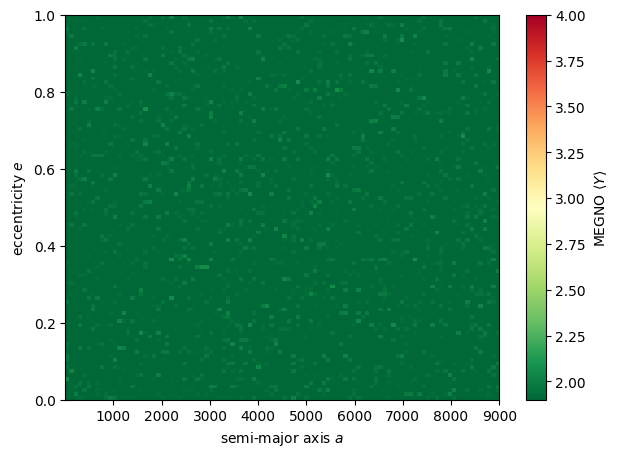

In [17]:
results2d = np.array(results).reshape(Ngrid,Ngrid)
%matplotlib inline
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(111)
extent = [min(par_a),max(par_a),min(par_e),max(par_e)]
ax.set_xlim(extent[0],extent[1])
ax.set_xlabel("semi-major axis $a$")
ax.set_ylim(extent[2],extent[3])
ax.set_ylabel("eccentricity $e$")
im = ax.imshow(results2d, interpolation="none", vmin=1.9, vmax=4, cmap="RdYlGn_r", origin="lower", aspect='auto', extent=extent)
cb = plt.colorbar(im, ax=ax)
cb.set_label("MEGNO $\\langle Y \\rangle$")